In [29]:
import pandas as pd
df = pd.read_csv('/kaggle/input/paysim1/PS_20174392719_1491204439457_log.csv').drop(['isFlaggedFraud', 'step'], axis = 1)
df

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud
0,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0
1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0
2,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1
3,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1
4,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0
...,...,...,...,...,...,...,...,...,...
6362615,CASH_OUT,339682.13,C786484425,339682.13,0.00,C776919290,0.00,339682.13,1
6362616,TRANSFER,6311409.28,C1529008245,6311409.28,0.00,C1881841831,0.00,0.00,1
6362617,CASH_OUT,6311409.28,C1162922333,6311409.28,0.00,C1365125890,68488.84,6379898.11,1
6362618,TRANSFER,850002.52,C1685995037,850002.52,0.00,C2080388513,0.00,0.00,1


In [30]:
print(df.info())
print(df.describe())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 9 columns):
 #   Column          Dtype  
---  ------          -----  
 0   type            object 
 1   amount          float64
 2   nameOrig        object 
 3   oldbalanceOrg   float64
 4   newbalanceOrig  float64
 5   nameDest        object 
 6   oldbalanceDest  float64
 7   newbalanceDest  float64
 8   isFraud         int64  
dtypes: float64(5), int64(1), object(3)
memory usage: 436.9+ MB
None
             amount  oldbalanceOrg  newbalanceOrig  oldbalanceDest  \
count  6.362620e+06   6.362620e+06    6.362620e+06    6.362620e+06   
mean   1.798619e+05   8.338831e+05    8.551137e+05    1.100702e+06   
std    6.038582e+05   2.888243e+06    2.924049e+06    3.399180e+06   
min    0.000000e+00   0.000000e+00    0.000000e+00    0.000000e+00   
25%    1.338957e+04   0.000000e+00    0.000000e+00    0.000000e+00   
50%    7.487194e+04   1.420800e+04    0.000000e+00    1.327057e+05   
75%    2.0

In [31]:
# !pip uninstall scikit-learn -y
# !pip uninstall imbalanced-learn -y
# !pip install scikit-learn==1.3.2
# !pip install imbalanced-learn==0.13.0

In [32]:
df['isFraud'].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [33]:
df.isna().sum()

type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
dtype: int64

In [34]:
cat_col = df.select_dtypes(include='object').columns
cat_col = [col for col in cat_col]
num_col = df.select_dtypes(exclude='object').columns
num_col = [num for num in num_col]

In [35]:
df2 = df.drop(['nameOrig', 'nameDest'], axis=1)
df2.head()

,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
0,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0,0
1,PAYMENT,1864.28,21249.0,19384.72,0.0,0.0,0
2,TRANSFER,181.00,181.0,0.00,0.0,0.0,1
3,CASH_OUT,181.00,181.0,0.00,21182.0,0.0,1
4,PAYMENT,11668.14,41554.0,29885.86,0.0,0.0,0


In [36]:
df3 =  df2[~(
            ((df['oldbalanceOrg'] == 0) & (df['amount'] > 0)) |
            (df['newbalanceOrig'] == df['oldbalanceOrg']) |
            ((df['oldbalanceDest'] == 0) & (df['newbalanceDest'] > 1e7))
        )]

In [37]:
df3.reset_index(drop=True)
df3.head()

,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
0,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0,0
1,PAYMENT,1864.28,21249.0,19384.72,0.0,0.0,0
2,TRANSFER,181.00,181.0,0.00,0.0,0.0,1
3,CASH_OUT,181.00,181.0,0.00,21182.0,0.0,1
4,PAYMENT,11668.14,41554.0,29885.86,0.0,0.0,0


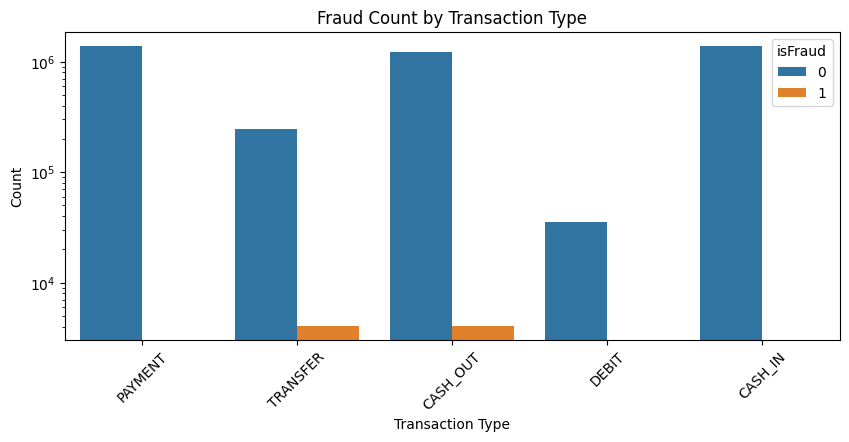

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 4))
sns.countplot(x='type', hue='isFraud', data=df3)
plt.yscale('log', base = 10)
plt.title('Fraud Count by Transaction Type')
plt.xlabel('Transaction Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

In [39]:
fraud_df = df3[df3['type'].isin(['TRANSFER', 'CASH_OUT'])]
fraud_df['isFraud'].value_counts()

isFraud
0    1453055
1       8156
Name: count, dtype: int64

In [40]:
df3['balanceDiffOrig'] = df3['oldbalanceOrg'] - df3['newbalanceOrig']
df3['balanceDiffDest'] = df3['oldbalanceDest'] - df3['newbalanceDest']

/tmp/ipykernel_171/2900625418.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3['balanceDiffOrig'] = df3['oldbalanceOrg'] - df3['newbalanceOrig']
/tmp/ipykernel_171/2900625418.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3['balanceDiffDest'] = df3['oldbalanceDest'] - df3['newbalanceDest']


In [41]:
df3

,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,balanceDiffOrig,balanceDiffDest
0,PAYMENT,9839.64,170136.00,160296.36,0.00,0.00,0,9839.64,0.00
1,PAYMENT,1864.28,21249.00,19384.72,0.00,0.00,0,1864.28,0.00
2,TRANSFER,181.00,181.00,0.00,0.00,0.00,1,181.00,0.00
3,CASH_OUT,181.00,181.00,0.00,21182.00,0.00,1,181.00,21182.00
4,PAYMENT,11668.14,41554.00,29885.86,0.00,0.00,0,11668.14,0.00
...,...,...,...,...,...,...,...,...,...
6362615,CASH_OUT,339682.13,339682.13,0.00,0.00,339682.13,1,339682.13,-339682.13
6362616,TRANSFER,6311409.28,6311409.28,0.00,0.00,0.00,1,6311409.28,0.00
6362617,CASH_OUT,6311409.28,6311409.28,0.00,68488.84,6379898.11,1,6311409.28,-6311409.27
6362618,TRANSFER,850002.52,850002.52,0.00,0.00,0.00,1,850002.52,0.00


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

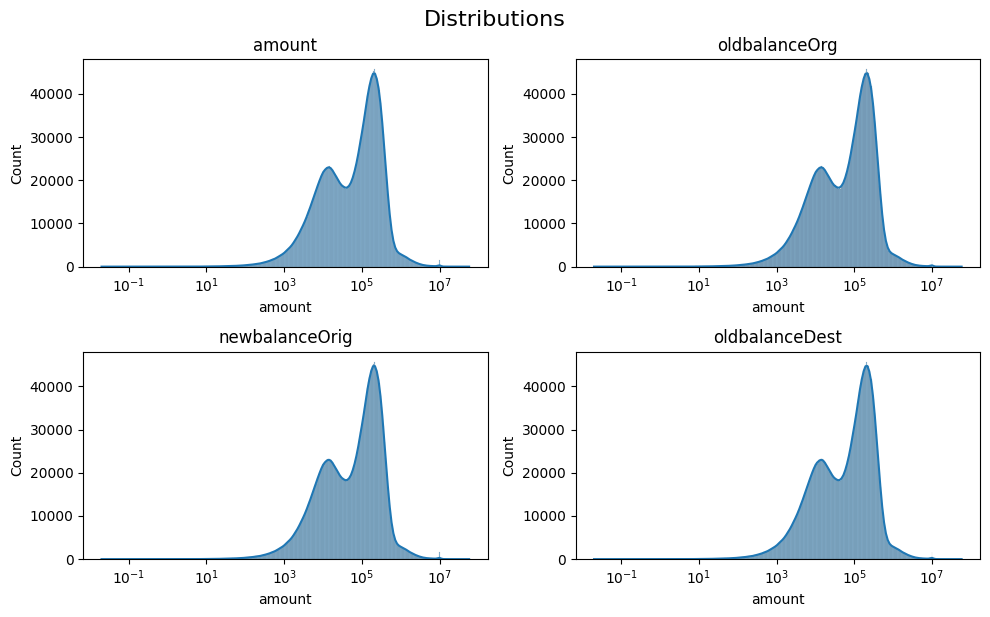

In [42]:
cols = ['amount',	'oldbalanceOrg',	'newbalanceOrig',	'oldbalanceDest']
plt.figure(figsize=(10, 6))
for i, col in enumerate(cols):
    plt.subplot(2, 2, i + 1)
    sns.histplot(df3['amount'], kde=True, log_scale=10)
    plt.title(col)
    plt.tight_layout()

plt.suptitle("Distributions", fontsize=16, y=1.02)
plt.show()

In [43]:
dummies = pd.get_dummies(df3['type'])
df3 = pd.concat([df3, dummies], axis=1)
df3.reset_index(drop=True, inplace=True)
print(df3.shape)
df3.tail()

(4259519, 14)


,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,balanceDiffOrig,balanceDiffDest,CASH_IN,CASH_OUT,DEBIT,PAYMENT,TRANSFER
4259514,CASH_OUT,339682.13,339682.13,0.0,0.00,339682.13,1,339682.13,-339682.13,False,True,False,False,False
4259515,TRANSFER,6311409.28,6311409.28,0.0,0.00,0.00,1,6311409.28,0.00,False,False,False,False,True
4259516,CASH_OUT,6311409.28,6311409.28,0.0,68488.84,6379898.11,1,6311409.28,-6311409.27,False,True,False,False,False
4259517,TRANSFER,850002.52,850002.52,0.0,0.00,0.00,1,850002.52,0.00,False,False,False,False,True
4259518,CASH_OUT,850002.52,850002.52,0.0,6510099.11,7360101.63,1,850002.52,-850002.52,False,True,False,False,False


In [44]:
df4 = df3.drop(['type'], axis=1)
df4 = df4.reset_index(drop=True)
print(df4['isFraud'].value_counts())
df4.sample(5)

isFraud
0    4251363
1       8156
Name: count, dtype: int64


,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,balanceDiffOrig,balanceDiffDest,CASH_IN,CASH_OUT,DEBIT,PAYMENT,TRANSFER
2247269,13469.90,249691.32,236221.42,0.00,0.00,0,13469.90,0.00,False,False,False,True,False
2738603,65972.35,109745.53,43773.18,0.00,0.00,0,65972.35,0.00,False,False,False,True,False
1415280,70551.52,10442036.66,10512588.18,677407.54,606856.02,0,-70551.52,70551.52,True,False,False,False,False
3106010,209839.89,4704822.90,4914662.79,563179.02,353339.14,0,-209839.89,209839.88,True,False,False,False,False
3678614,268691.72,62579.00,0.00,3814234.02,4082925.74,0,62579.00,-268691.72,False,False,False,False,True


<Axes: >

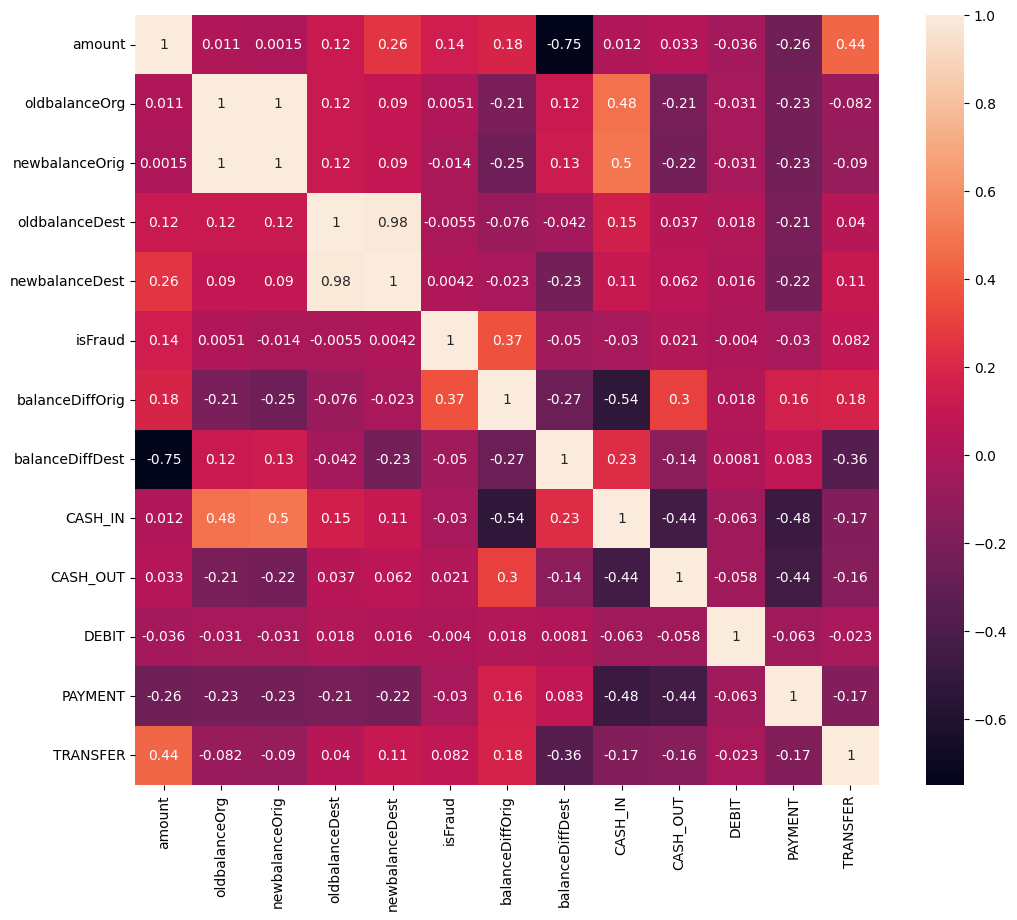

In [45]:
plt.figure(figsize=(12,10))
sns.heatmap(df4.corr(), annot=True)

<Axes: >

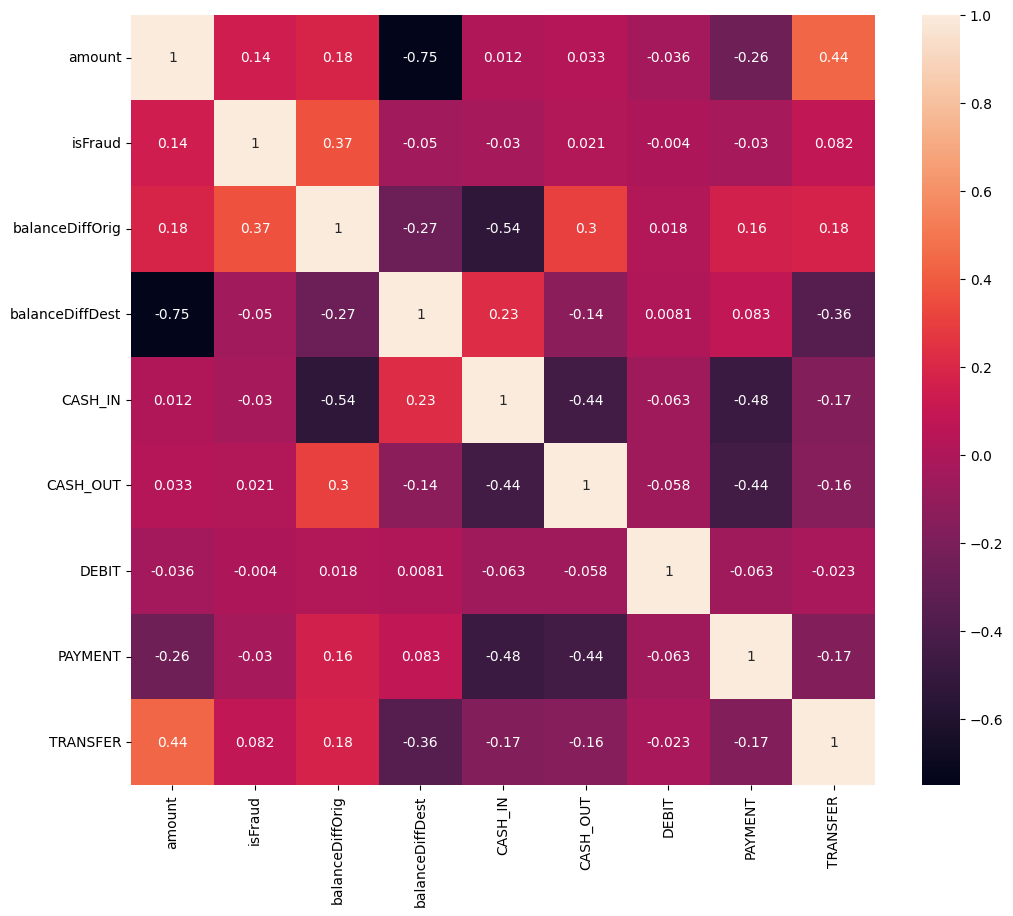

In [46]:
df5 = df4.drop(['oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest'], axis=1)


corr = df5.corr()
plt.figure(figsize=(12,10))
sns.heatmap(corr, annot=True)

In [47]:
from sklearn.utils import resample

df_majority = df5[df5.isFraud == 0]
df_minority = df5[df5.isFraud == 1]

df_majority_downsampled = resample(
    df_majority, 
    replace=False, 
    n_samples=8156, 
    random_state=42
)

df_balanced = pd.concat([df_majority_downsampled, df_minority], axis=0)

In [48]:
df_balanced.reset_index(drop=True, inplace=True)
df_balanced.head()

,amount,isFraud,balanceDiffOrig,balanceDiffDest,CASH_IN,CASH_OUT,DEBIT,PAYMENT,TRANSFER
0,498385.90,0,103867.00,-498385.90,False,False,False,False,True
1,113961.34,0,-113961.35,113961.34,True,False,False,False,False
2,12766.05,0,12766.05,0.00,False,False,False,True,False
3,326760.21,0,-326760.21,-181429.36,True,False,False,False,False
4,16294.33,0,10940.00,0.00,False,False,False,True,False


In [49]:
df_type = df_balanced[['CASH_IN','CASH_OUT','DEBIT','PAYMENT','TRANSFER','isFraud']]
from sklearn.preprocessing import  StandardScaler
sc = StandardScaler()
scaled = sc.fit_transform(df_balanced[['amount','balanceDiffOrig','balanceDiffDest']])
scaled_df = pd.DataFrame(scaled, columns=['amount', 'balanceDiffOrig', 'balanceDiffDest'])
df_final = pd.concat([scaled_df, df_type], axis=1)
df_final

,amount,balanceDiffOrig,balanceDiffDest,CASH_IN,CASH_OUT,DEBIT,PAYMENT,TRANSFER,isFraud
0,-0.173381,-0.330027,-0.063831,False,False,False,False,True,0
1,-0.382611,-0.447236,0.365680,True,False,False,False,False,0
2,-0.437689,-0.379047,0.285745,False,False,False,True,False,0
3,-0.266791,-0.561739,0.158488,True,False,False,False,False,0
4,-0.435768,-0.380030,0.285745,False,False,False,True,False,0
...,...,...,...,...,...,...,...,...,...
16307,-0.259758,-0.203140,0.047487,False,True,False,False,False,1
16308,2.990470,3.010122,0.285745,False,False,False,False,True,1
16309,2.990470,3.010122,-4.141181,False,True,False,False,False,1
16310,0.017994,0.071453,0.285745,False,False,False,False,True,1


In [50]:
X = df_final.drop('isFraud', axis=1)
y = df_final['isFraud']
X.shape, y.shape

((16312, 8), (16312,))

In [51]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [52]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

In [53]:
scale_weight = y_train.value_counts()[0] / y_train.value_counts()[1]
scale_weight

1.0

In [54]:
from sklearn.metrics import classification_report
from xgboost import XGBClassifier

xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    n_estimators=100,
    learning_rate=0.1,
    max_depth=8,
)

xgb.fit(X_train, y_train)
print(classification_report(y_test, xgb.predict(X_test)))

              precision    recall  f1-score   support

           0       0.99      0.94      0.96      1632
           1       0.94      0.99      0.97      1631

    accuracy                           0.97      3263
   macro avg       0.97      0.97      0.97      3263
weighted avg       0.97      0.97      0.97      3263



In [55]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=100, max_depth=8, class_weight='balanced', random_state=42)
rf_model.fit(X_train, y_train)
print(classification_report(y_test, rf_model.predict(X_test)))

              precision    recall  f1-score   support

           0       1.00      0.93      0.96      1632
           1       0.93      1.00      0.96      1631

    accuracy                           0.96      3263
   macro avg       0.97      0.96      0.96      3263
weighted avg       0.97      0.96      0.96      3263



In [56]:
!pip install lazypredict --quiet

In [57]:
from lazypredict.Supervised import LazyClassifier

clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=None)
models, predictions = clf.fit(X_train, X_test, y_train, y_test)

print(models)

  0%|          | 0/29 [00:00<?, ?it/s]

[LightGBM] [Info] Number of positive: 6525, number of negative: 6525
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000382 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 13050, number of used features: 3
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
                               Accuracy  Balanced Accuracy  ROC AUC  F1 Score  \
Model                                                                           
XGBClassifier                      0.93               0.93     0.93      0.93   
LGBMClassifier                     0.93               0.93     0.93      0.93   
AdaBoostClassifier                 0.93               0.93     0.93      0.93   
KNeighborsClassifier               0.92               0.92     0.92      0.92   
Perceptron                         0.92               0.92     0.92      0.92  